# 01 — Data Exploration

Explore the processed OpenXAI datasets (Adult Income, German Credit) and their attached SHAP values.
This notebook is for exploration only — do not run the pipeline from here.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv('../.env')
sns.set_theme(style='whitegrid', context='notebook')

In [2]:
from src.config import load_config
from src.data_loader import load_dataset, get_shap_columns, get_feature_columns, format_shap_table

cfg = load_config('../config/default.yaml')
print('Datasets:', [d.name for d in cfg.datasets])
print('Models:  ', [m.id for m in cfg.models])

Datasets: ['adult', 'german_credit']
Models:   ['claude-opus', 'llama3-70b', 'mistral-7b']


## Adult Income dataset

In [6]:
adult_cfg = cfg.get_dataset('adult')
adult = load_dataset(adult_cfg)
print(f'Shape: {adult.shape}')
adult.head()

Shape: (100, 27)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,shap_education,shap_education_num,shap_marital_status,shap_occupation,shap_relationship,shap_race,shap_sex,shap_capital_gain,shap_capital_loss,shap_hours_per_week
0,0.136986,0.151121,0.533333,0.0,0.0,0.193878,1.0,1.0,1.0,1.0,...,0.015449,-0.015931,-0.014181,0.035415,0.001184,0.056191,0.025457,0.034562,-0.012225,0.003258
1,0.273973,0.070657,0.733333,0.0,0.0,0.295918,0.0,1.0,1.0,1.0,...,-0.011752,-0.004191,-0.015017,-0.001456,-0.003869,0.254434,0.076235,0.054454,0.005109,0.011982
2,0.452055,0.197689,0.866667,0.0,0.0,0.397959,1.0,0.0,0.0,1.0,...,0.011553,0.001090,0.070818,-0.118084,0.003844,-0.000681,-0.094536,0.016005,0.000477,0.004045
3,0.109589,0.144896,0.533333,0.0,0.0,0.397959,0.0,1.0,1.0,1.0,...,0.003692,0.009185,-0.031441,-0.003675,0.015032,0.108914,0.040004,0.041275,-0.004666,-0.000397
4,0.178082,0.195471,0.466667,0.0,0.0,0.397959,0.0,1.0,1.0,1.0,...,0.000516,0.011155,-0.032767,0.001850,0.003998,0.096193,0.044621,0.044776,-0.015918,-0.014757


In [7]:
shap_cols = get_shap_columns(adult, adult_cfg.shap_col_prefix)
feat_cols = get_feature_columns(adult, adult_cfg.shap_col_prefix)
print('Feature columns:', feat_cols)
print('SHAP columns:   ', shap_cols)

Feature columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'label']
SHAP columns:    ['shap_age', 'shap_workclass', 'shap_fnlwgt', 'shap_education', 'shap_education_num', 'shap_marital_status', 'shap_occupation', 'shap_relationship', 'shap_race', 'shap_sex', 'shap_capital_gain', 'shap_capital_loss', 'shap_hours_per_week']


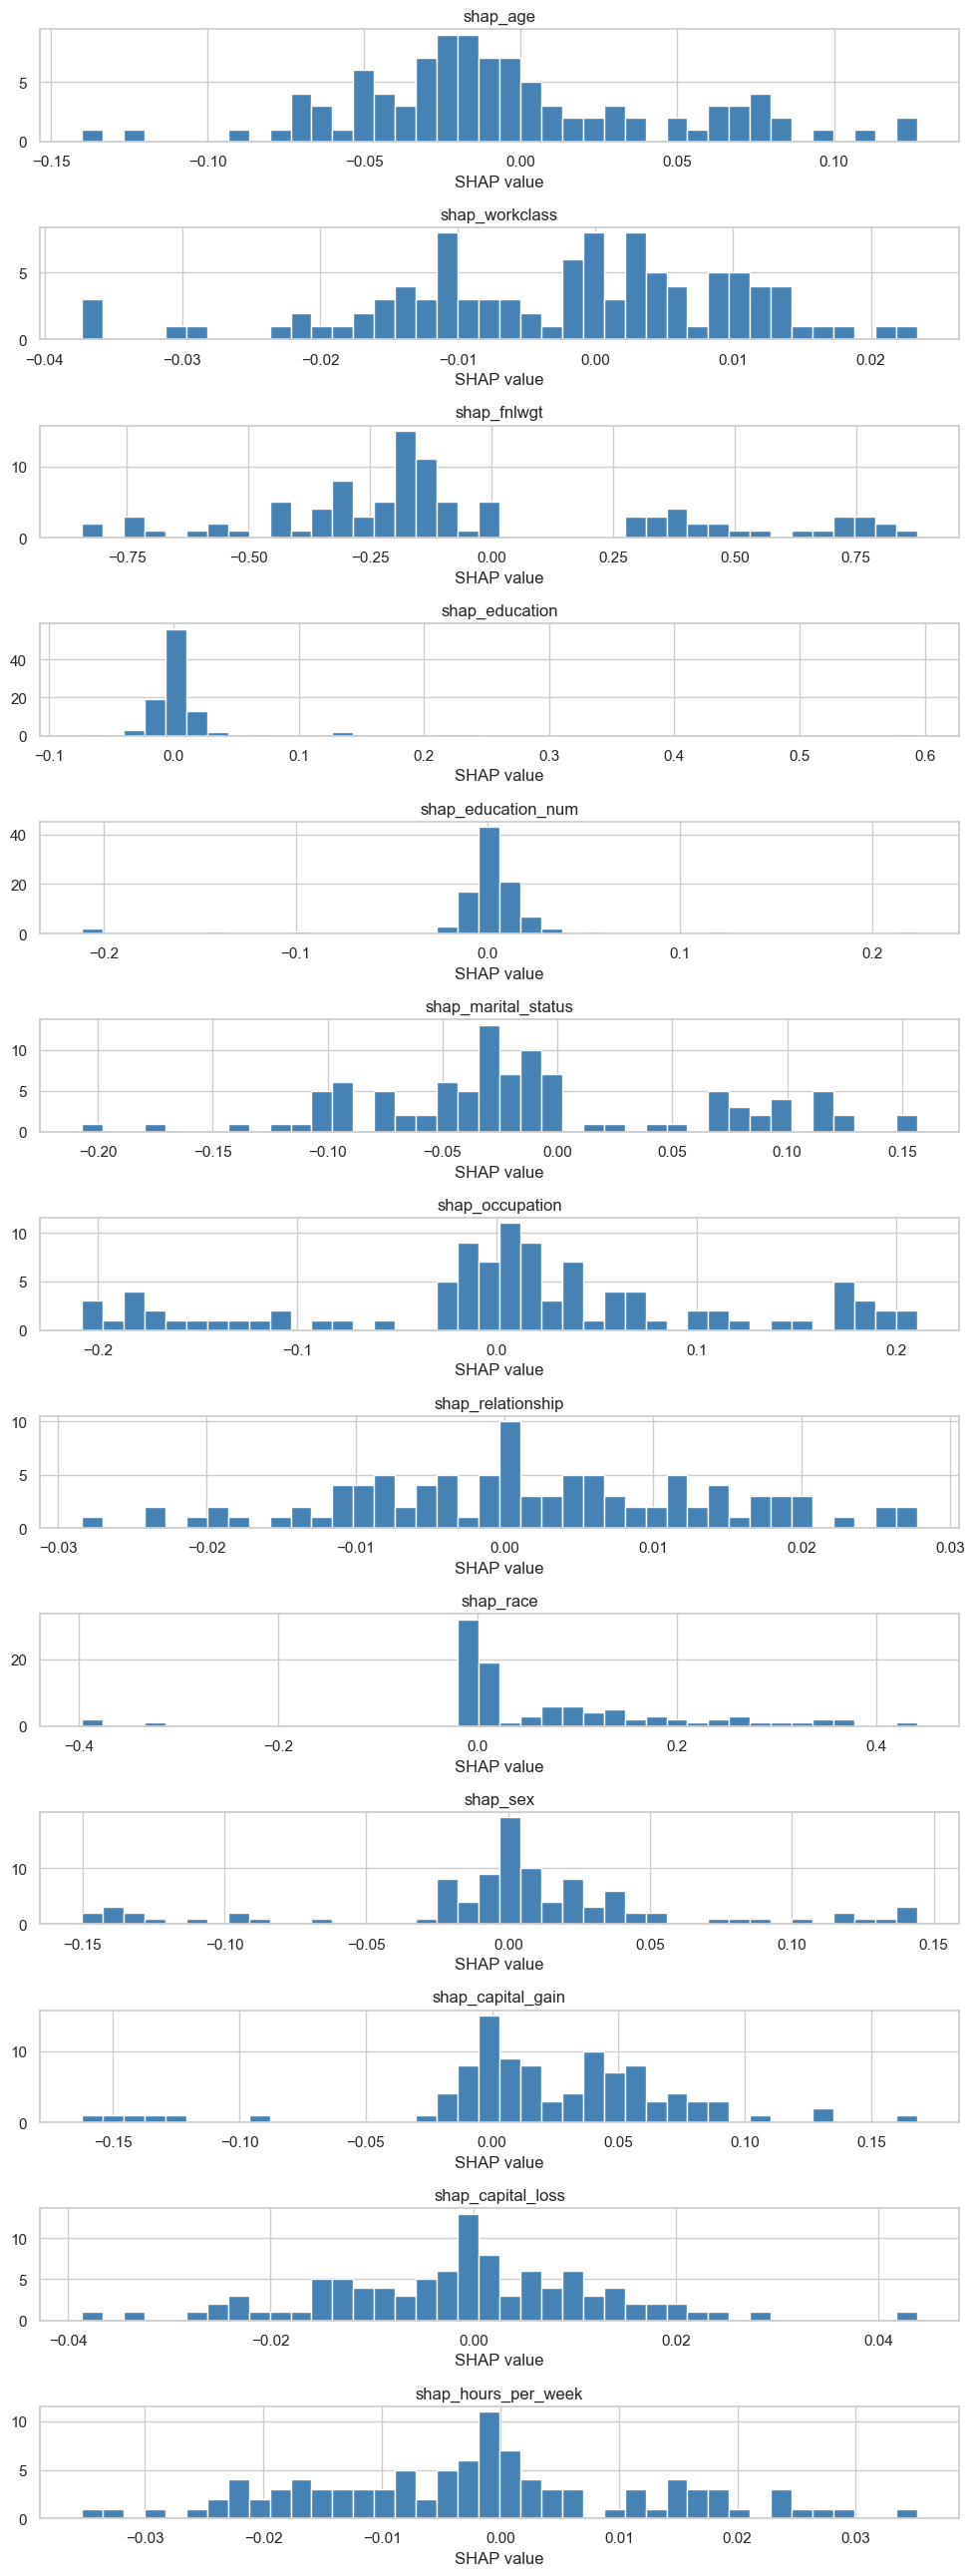

In [8]:
# Distribution of SHAP values across all instances
fig, axes = plt.subplots(len(shap_cols), 1, figsize=(10, 2 * len(shap_cols)))
if len(shap_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, shap_cols):
    adult[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('SHAP value')
plt.tight_layout()
plt.show()

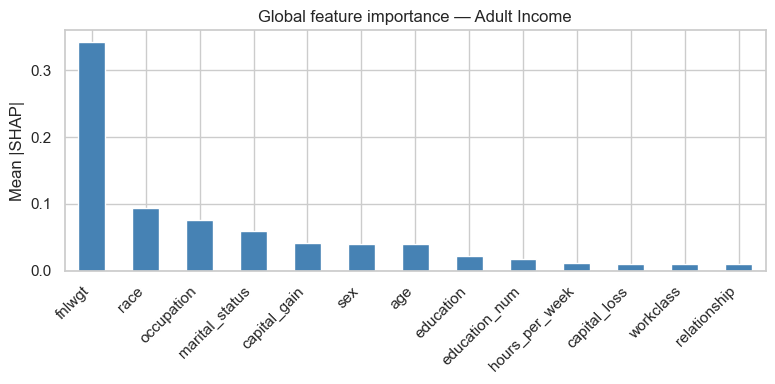

In [9]:
# Mean absolute SHAP value per feature (global importance)
mean_abs = adult[shap_cols].abs().mean().sort_values(ascending=False)
mean_abs.index = [c.replace(adult_cfg.shap_col_prefix, '') for c in mean_abs.index]

fig, ax = plt.subplots(figsize=(8, 4))
mean_abs.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_ylabel('Mean |SHAP|')
ax.set_title('Global feature importance — Adult Income')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
# Inspect a single instance prompt
row = adult.iloc[0]
print(format_shap_table(row, adult_cfg.shap_col_prefix))

  fnlwgt: -0.1155 (feature value: 0.5333333333333333)
  race: +0.0562 (feature value: 1.0)
  occupation: +0.0354 (feature value: 1.0)
  capital_gain: +0.0346 (feature value: 1.0)
  sex: +0.0255 (feature value: 1.0)
  education_num: -0.0159 (feature value: 0.0)
  education: +0.0154 (feature value: 0.0)
  marital_status: -0.0142 (feature value: 0.1938775510204081)
  capital_loss: -0.0122 (feature value: 0.0)
  workclass: -0.0038 (feature value: 0.1511208354451977)
  hours_per_week: +0.0033 (feature value: 1.0)
  age: +0.0031 (feature value: 0.136986301369863)
  relationship: +0.0012 (feature value: 1.0)


## German Credit dataset

In [ ]:
german_cfg = cfg.get_dataset('german_credit')
german = load_dataset(german_cfg)
print(f'Shape: {german.shape}')
german.head()

In [ ]:
shap_cols_g = get_shap_columns(german, german_cfg.shap_col_prefix)
mean_abs_g = german[shap_cols_g].abs().mean().sort_values(ascending=False)
mean_abs_g.index = [c.replace(german_cfg.shap_col_prefix, '') for c in mean_abs_g.index]

fig, ax = plt.subplots(figsize=(8, 4))
mean_abs_g.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_ylabel('Mean |SHAP|')
ax.set_title('Global feature importance — German Credit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()